# Notebook 3: GA-based Black-Box Adversarial Attack

**Goal:** Use Genetic Algorithm to generate adversarial examples WITHOUT accessing model weights.

**Key difference from FGSM/PGD:** We only query the model input→output, no gradients needed.

**Output:** GA attack success rates, comparison with baselines, fitness evolution plots.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
sys.path.append('../')

from src.model import CNN
from src.ga import GeneticAttack

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)
model.load_state_dict(torch.load('../results/model.pth', map_location=device))
model.eval()
print(f'Model loaded. Device: {device}')

Model loaded. Device: cpu


In [2]:
# Load test data
transform = transforms.Compose([
    transforms.ToTensor(),
])
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=False, transform=transform)
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

In [3]:
# Initialize GA attacker
ga = GeneticAttack(
    model=model,
    population_size=100,
    generations=50,
    mutation_rate=0.1,
    mutation_strength=0.08,
    epsilon=0.1,
    device=device
)

print('GA attacker initialized.')
print(f'Population: {ga.population_size} | Generations: {ga.generations} | Epsilon: {ga.epsilon}')

GA attacker initialized.
Population: 100 | Generations: 50 | Epsilon: 0.1


Attacking image of class: cat


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


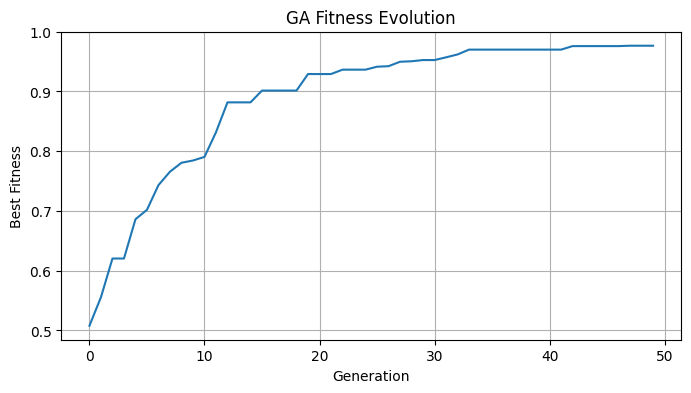

In [4]:
# Attack a single image and visualize fitness evolution
image, true_label = testset[0]
image_np = image.numpy()  # (C, H, W)

print(f'Attacking image of class: {classes[true_label]}')

perturbation, history = ga.attack(image_np, true_label)

# Plot fitness evolution
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('GA Fitness Evolution')
plt.grid(True)
plt.savefig('../results/figures/ga_fitness_evolution.png', dpi=150)
plt.show()

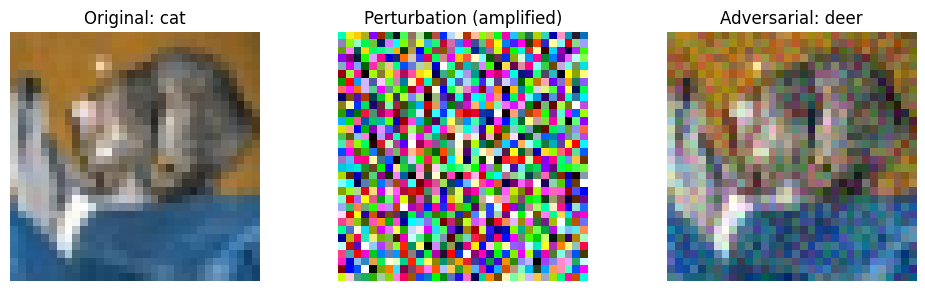

Original prediction: cat
Adversarial prediction: deer
Attack success: True


In [5]:
# Visualize: original vs adversarial
adv_image = np.clip(image_np + perturbation, 0, 1)

adv_tensor = torch.FloatTensor(adv_image).unsqueeze(0).to(device)
orig_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    orig_pred = model(orig_tensor).argmax(dim=1).item()
    adv_pred  = model(adv_tensor).argmax(dim=1).item()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(image_np.transpose(1,2,0))
axes[0].set_title(f'Original: {classes[true_label]}')
axes[1].imshow(perturbation.transpose(1,2,0) * 5 + 0.5)  # amplified for visibility
axes[1].set_title('Perturbation (amplified)')
axes[2].imshow(adv_image.transpose(1,2,0))
axes[2].set_title(f'Adversarial: {classes[adv_pred]}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/ga_adversarial_example.png', dpi=150)
plt.show()

print(f'Original prediction: {classes[orig_pred]}')
print(f'Adversarial prediction: {classes[adv_pred]}')
print(f'Attack success: {orig_pred != adv_pred}')

In [6]:
# Evaluate GA attack success rate on N samples
N_SAMPLES = 100 # increase to 500 for final results
success_count = 0
perturbation_norms = []

for i in tqdm(range(N_SAMPLES)):
    image, true_label = testset[i]
    image_np = image.numpy()

    # Only attack correctly classified images
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    if pred != true_label:
        continue

    perturbation, _ = ga.attack(image_np, true_label)
    adv = np.clip(image_np + perturbation, 0, 1)

    with torch.no_grad():
        adv_pred = model(torch.FloatTensor(adv).unsqueeze(0).to(device)).argmax(dim=1).item()

    if adv_pred != true_label:
        success_count += 1

    perturbation_norms.append(np.linalg.norm(perturbation))

asr = success_count / N_SAMPLES
avg_norm = np.mean(perturbation_norms)
print(f'GA Attack Success Rate: {asr:.3f}')
print(f'Average perturbation norm: {avg_norm:.4f}')

100%|██████████| 100/100 [03:51<00:00,  2.31s/it]

GA Attack Success Rate: 0.260
Average perturbation norm: 4.0548


In [8]:
# Hyperparameter search — ~15 min total (30 samples × 12 configs)
# Варьируем epsilon, generations, mutation_strength, mutation_rate
# population_size держим умеренным чтобы не выйти за бюджет времени

SEARCH_SAMPLES = 30  # достаточно для грубой оценки ASR

configs = [
    # (pop, gen, mut_rate, mut_strength, epsilon, label)
    (50,  30, 0.10, 0.05, 0.10, "baseline"),
    (50,  60, 0.10, 0.05, 0.10, "more_gen"),
    (50,  30, 0.10, 0.05, 0.15, "bigger_eps"),
    (50,  60, 0.10, 0.05, 0.15, "more_gen+eps"),
    (50,  30, 0.20, 0.05, 0.10, "high_mut_rate"),
    (50,  30, 0.10, 0.12, 0.10, "high_mut_str"),
    (50,  30, 0.20, 0.12, 0.10, "high_rate+str"),
    (80,  40, 0.10, 0.08, 0.10, "bigger_pop"),
    (80,  40, 0.15, 0.08, 0.12, "balanced+eps"),
    (50,  50, 0.15, 0.10, 0.15, "explore_eps15"),
    (80,  50, 0.20, 0.10, 0.12, "all_up_eps12"),
    (100, 50, 0.20, 0.10, 0.15, "max_effort"),
]

results = []

for pop, gen, mr, ms, eps, label in configs:
    ga_tmp = GeneticAttack(
        model=model,
        population_size=pop,
        generations=gen,
        mutation_rate=mr,
        mutation_strength=ms,
        epsilon=eps,
        device=device,
    )
    np.random.seed(45)
    indices = np.random.choice(len(testset), SEARCH_SAMPLES, replace=False)

    success, norms = 0, []
    for i in indices:
        image, true_label = testset[i]
        image_np = image.numpy()

        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
        if pred != true_label:
            continue

        perturbation, _ = ga_tmp.attack(image_np, true_label)
        adv = np.clip(image_np + perturbation, 0, 1)

        with torch.no_grad():
            adv_pred = model(torch.FloatTensor(adv).unsqueeze(0).to(device)).argmax(dim=1).item()

        if adv_pred != true_label:
            success += 1
        norms.append(np.linalg.norm(perturbation))

    asr = success / SEARCH_SAMPLES
    avg_norm = np.mean(norms)
    results.append((label, asr, avg_norm, pop, gen, mr, ms, eps))
    print(f"[{label:20s}] pop={pop:3d} gen={gen:3d} eps={eps:.2f} mr={mr:.2f} ms={ms:.2f} | ASR={asr:.3f} norm={avg_norm:.3f}")

# Итог — топ-3 по ASR
print("\n--- TOP-3 по ASR ---")
for r in sorted(results, key=lambda x: x[1], reverse=True)[:3]:
    print(f"  {r[0]:20s} ASR={r[1]:.3f} norm={r[2]:.3f}")

[baseline            ] pop= 50 gen= 30 eps=0.10 mr=0.10 ms=0.05 | ASR=0.200 norm=3.651
[more_gen            ] pop= 50 gen= 60 eps=0.10 mr=0.10 ms=0.05 | ASR=0.200 norm=3.794
[bigger_eps          ] pop= 50 gen= 30 eps=0.15 mr=0.10 ms=0.05 | ASR=0.200 norm=5.147
[more_gen+eps        ] pop= 50 gen= 60 eps=0.15 mr=0.10 ms=0.05 | ASR=0.200 norm=5.338
[high_mut_rate       ] pop= 50 gen= 30 eps=0.10 mr=0.20 ms=0.05 | ASR=0.167 norm=3.773
[high_mut_str        ] pop= 50 gen= 30 eps=0.10 mr=0.10 ms=0.12 | ASR=0.167 norm=4.173
[high_rate+str       ] pop= 50 gen= 30 eps=0.10 mr=0.20 ms=0.12 | ASR=0.167 norm=4.357
[bigger_pop          ] pop= 80 gen= 40 eps=0.10 mr=0.10 ms=0.08 | ASR=0.200 norm=3.981
[balanced+eps        ] pop= 80 gen= 40 eps=0.12 mr=0.15 ms=0.08 | ASR=0.200 norm=4.750
[explore_eps15       ] pop= 50 gen= 50 eps=0.15 mr=0.15 ms=0.10 | ASR=0.200 norm=5.974
[all_up_eps12        ] pop= 80 gen= 50 eps=0.12 mr=0.20 ms=0.10 | ASR=0.200 norm=5.029
[max_effort          ] pop=100 gen= 50 eps=

Обучаем автоэнкодер: латент 128 чисел вместо 3072 пикселей
10 эпох на 5000 картинок (~2 мин)...
  Epoch 1/10 | Recon Loss: 0.0582
  Epoch 2/10 | Recon Loss: 0.0343
  Epoch 3/10 | Recon Loss: 0.0265
  Epoch 4/10 | Recon Loss: 0.0230
  Epoch 5/10 | Recon Loss: 0.0207
  Epoch 6/10 | Recon Loss: 0.0190
  Epoch 7/10 | Recon Loss: 0.0177
  Epoch 8/10 | Recon Loss: 0.0153
  Epoch 9/10 | Recon Loss: 0.0143
  Epoch 10/10 | Recon Loss: 0.0133
Сохранён: results/autoencoder.pth


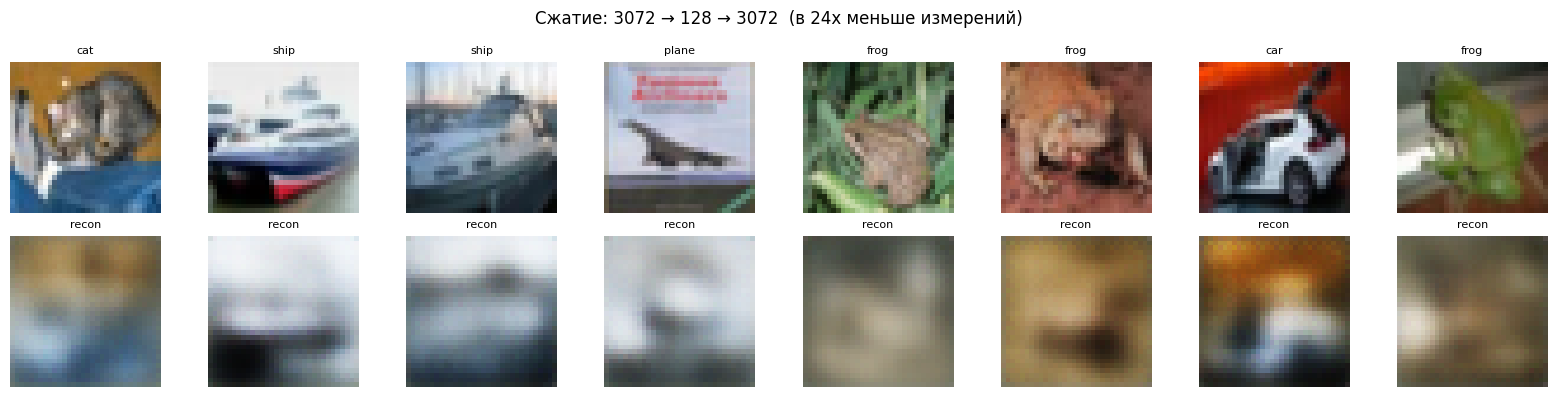

In [9]:
import torch.nn as nn
import torch.optim as optim

# Простой свёрточный автоэнкодер для CIFAR-10
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 32→16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16→8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8→4
            nn.ReLU(),
            nn.Flatten(),                                # 128*4*4=2048
            nn.Linear(2048, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 2048)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 4→8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 8→16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # 16→32
            nn.Sigmoid(),  # выход в [0,1]
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 128, 4, 4))

LATENT_DIM = 128
encoder = Encoder(LATENT_DIM).to(device)
decoder = Decoder(LATENT_DIM).to(device)

# Обучаем на 5000 картинок без нормализации (пиксели в [0,1])
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=False, transform=raw_transform)
ae_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(raw_trainset, range(5000)), batch_size=128, shuffle=True
)

optimizer_ae = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
mse = nn.MSELoss()

print(f"Обучаем автоэнкодер: латент {LATENT_DIM} чисел вместо 3072 пикселей")
print("10 эпох на 5000 картинок (~2 мин)...")
for epoch in range(10):
    total_loss = 0
    for imgs, _ in ae_loader:
        imgs = imgs.to(device)
        loss = mse(decoder(encoder(imgs)), imgs)
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/10 | Recon Loss: {total_loss/len(ae_loader):.4f}")

torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict()},
           '../results/autoencoder.pth')
print("Сохранён: results/autoencoder.pth")

# Визуализация: оригинал vs реконструкция через автоэнкодер
raw_testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=False, transform=raw_transform)
encoder.eval(); decoder.eval()

N_VIZ = 8
fig, axes = plt.subplots(2, N_VIZ, figsize=(16, 4))

for i in range(N_VIZ):
    img, label = raw_testset[i]
    with torch.no_grad():
        recon = decoder(encoder(img.unsqueeze(0).to(device))).squeeze(0).cpu()

    axes[0, i].imshow(img.permute(1, 2, 0).numpy())
    axes[0, i].set_title(classes[label], fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(recon.permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].set_title('recon', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Оригинал\n(3072 числа)', fontsize=9)
axes[1, 0].set_ylabel(f'Автоэнкодер\n({LATENT_DIM} чисел)', fontsize=9)
plt.suptitle(f'Сжатие: 3072 → {LATENT_DIM} → 3072  (в {3072//LATENT_DIM}x меньше измерений)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/autoencoder_reconstruction.png', dpi=150)
plt.show()